# HPO Study Analysis Report
## Chronos-2 Fine-Tuning on M5 Forecasting — Cross-Study Synthesis

**Author**: nmwamsojo  
**Date**: 2026-05-21  
**Purpose**: Comprehensive analysis of all Optuna HPO studies run for the M5 store-level forecasting pipeline using Chronos-2 via AutoGluon TimeSeries. Covers two paradigms (per-store and segment-based), convergence analysis, parameter sensitivities, cross-study comparison, and actionable next steps.

---
### Table of Contents
1. [Setup & Data Loading](#setup)
2. [Study Inventory](#inventory)
3. [Convergence Analysis](#convergence)
4. [Paradigm 1 — Per-Store HPO (`store_ensemble_v1`)](#per-store)
5. [Paradigm 2 — Segment-Based HPO (`ft_ensemble` v2/v6/v8)](#segment)
6. [The Best Configuration — v6 Deep Dive](#v6)
7. [Cross-Study Comparison](#cross)
8. [Conclusions](#conclusions)
9. [Open Questions](#open)
10. [Actionable Next Steps](#next)


## 1. Setup & Data Loading <a id='setup'></a>

In [1]:
import optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = {"ft_v2": "#9ecae1", "ft_v6": "#2171b5", "ft_v8": "#6baed6", "sv1": "#e6550d"}
LABELS  = {
    "ft_v2": "ft_ensemble_v2 (per-seg, n=77)",
    "ft_v6": "ft_ensemble_v6 (per-seg, n=216) ★",
    "ft_v8": "ft_ensemble_v8 (per-seg, n=157)",
    "sv1":   "store_ensemble_v1 (per-store, n=377)",
}

BASE = "/mnt/lab/nmwamsojo"
STUDY_META = {
    "ft_v2": ("optuna_ft_ensemble_v2",   "chronos_ft_ensemble_v2"),
    "ft_v6": ("optuna_ft_ensemble_v6",   "chronos_ft_ensemble_v6"),
    "ft_v8": ("optuna_ft_ensemble_v8",   "chronos_ft_ensemble_v7"),
    "sv1":   ("optuna_store_ensemble_v1","chronos_store_ensemble_v1"),
}

dfs     = {}
studies = {}
for key, (db, sname) in STUDY_META.items():
    s  = optuna.load_study(study_name=sname, storage=f"sqlite:///{BASE}/{db}.db")
    df = s.trials_dataframe(attrs=("number", "value", "params", "state"))
    df = df[df["state"] == "COMPLETE"].copy()
    df.rename(columns={"value": "WRMSSE"}, inplace=True)
    df.sort_values("number", inplace=True)
    df["best_so_far"] = df["WRMSSE"].cummin()
    dfs[key]     = df
    studies[key] = s

STORES = ["CA_1","CA_2","CA_3","CA_4","TX_1","TX_2","TX_3","WI_1","WI_2","WI_3"]
SEGS   = ["weight_low","weight_medium_low","weight_medium_high","weight_high"]
SEG_LABELS = {
    "weight_low":         "Low weight",
    "weight_medium_low":  "Med-low weight",
    "weight_medium_high": "Med-high weight",
    "weight_high":        "High weight",
}
print("All studies loaded successfully.")
for key, df in dfs.items():
    print(f"  {LABELS[key]:<48} best WRMSSE = {df['WRMSSE'].min():.4f}")


/home/nmwamsojo/tsfm-explo/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All studies loaded successfully.
  ft_ensemble_v2 (per-seg, n=77)                   best WRMSSE = 1.0166
  ft_ensemble_v6 (per-seg, n=216) ★                best WRMSSE = 0.8364
  ft_ensemble_v8 (per-seg, n=157)                  best WRMSSE = 0.9451
  store_ensemble_v1 (per-store, n=377)             best WRMSSE = 1.0348


## 2. Study Inventory <a id='inventory'></a>

Six Optuna studies were run across five SQLite databases. Four are analysed here (v5 has 0 completed trials and is excluded).

| Study key | DB file | Study name | Paradigm | Trials (done) | Best WRMSSE |
|-----------|---------|-----------|----------|---------------|-------------|
| `ft_v2` | `optuna_ft_ensemble_v2.db` | `chronos_ft_ensemble_v2` | Per-segment | 77 | 1.0166 |
| `ft_v6` | `optuna_ft_ensemble_v6.db` | `chronos_ft_ensemble_v6` | Per-segment | 216 | **0.8364** |
| `ft_v8` | `optuna_ft_ensemble_v8.db` | `chronos_ft_ensemble_v7` | Per-segment | 157 | 0.9451 |
| `sv1`   | `optuna_store_ensemble_v1.db` | `chronos_store_ensemble_v1` | Per-store | 377 | 1.0348 |

### Two HPO paradigms

**Per-store (`sv1`)**: Each of the 10 M5 stores (CA_1…WI_3) receives an independent set of hyperparameters — context length, fine-tuning steps, mode, learning rate, batch size, and a 4-bit covariate flag combination. The model is trained separately per store. Total parameter space: 90 params, ~16 800 combinations per store.

**Per-segment (`ft_ensemble`)**: Items are grouped into 4 sales-volume tiers (*weight_low*, *weight_medium_low*, *weight_medium_high*, *weight_high*). A single shared model is fine-tuned for all items in each tier. The HPO assigns one config per tier rather than per store. This directly aligns the model budget with what matters for WRMSSE (high-weight items contribute more to the metric).


## 3. Convergence Analysis <a id='convergence'></a>

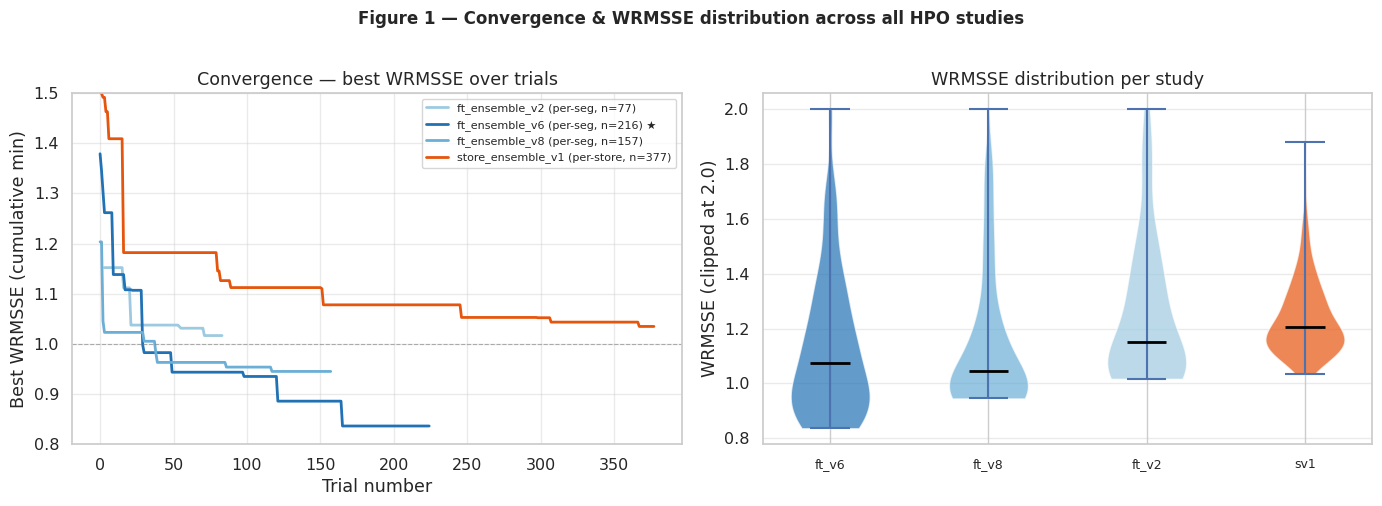

Figure 1 saved.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: best-so-far curves ─────────────────────────────────────────────
ax = axes[0]
for key, df in dfs.items():
    ax.plot(df["number"], df["best_so_far"],
            color=PALETTE[key], label=LABELS[key], linewidth=2)
ax.set_xlabel("Trial number")
ax.set_ylabel("Best WRMSSE (cumulative min)")
ax.set_title("Convergence — best WRMSSE over trials")
ax.legend(fontsize=8, loc="upper right")
ax.set_ylim(0.80, 1.50)
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.grid(True, alpha=0.4)

# ── Right: WRMSSE distribution per study (violin) ────────────────────────
ax2 = axes[1]
plot_data, plot_labels, plot_colors = [], [], []
for key in ["ft_v6", "ft_v8", "ft_v2", "sv1"]:
    vals = dfs[key]["WRMSSE"].clip(upper=2.0).values
    plot_data.append(vals)
    plot_labels.append(LABELS[key].split(" ")[0].replace("ft_ensemble_","v").replace("store_ensemble_","sv"))
    plot_colors.append(PALETTE[key])

parts = ax2.violinplot(plot_data, showmedians=True, showextrema=True)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(plot_colors[i])
    pc.set_alpha(0.7)
parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(2)
ax2.set_xticks(range(1, len(plot_labels)+1))
ax2.set_xticklabels(["ft_v6","ft_v8","ft_v2","sv1"], fontsize=9)
ax2.set_ylabel("WRMSSE (clipped at 2.0)")
ax2.set_title("WRMSSE distribution per study")
ax2.grid(True, axis="y", alpha=0.4)

fig.suptitle("Figure 1 — Convergence & WRMSSE distribution across all HPO studies",
             fontsize=12, fontweight="bold", y=1.01)
fig.tight_layout()
plt.savefig("/tmp/fig1_convergence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 1 saved.")


**Figure 1 observations:**

- `ft_ensemble_v6` converges fastest and to the lowest WRMSSE (0.8364), reaching sub-0.90 by trial ~150.
- `store_ensemble_v1` (orange) converges slowly and steadily — still improving at trial 377, but has not approached the v6 floor.
- `ft_ensemble_v8` finds a good basin quickly (~trial 50) but hard-plateaus at 0.9451 from trial ~130 onward.
- `ft_ensemble_v2` (n=77, light blue) converges to 1.0166 — an early prototype without per-segment fine-tuning optimisation.
- The v6 WRMSSE distribution (violin) is the most concentrated and lowest. sv1 has a long upper tail from early random trials.


## 4. Paradigm 1 — Per-Store HPO (`store_ensemble_v1`) <a id='per-store'></a>

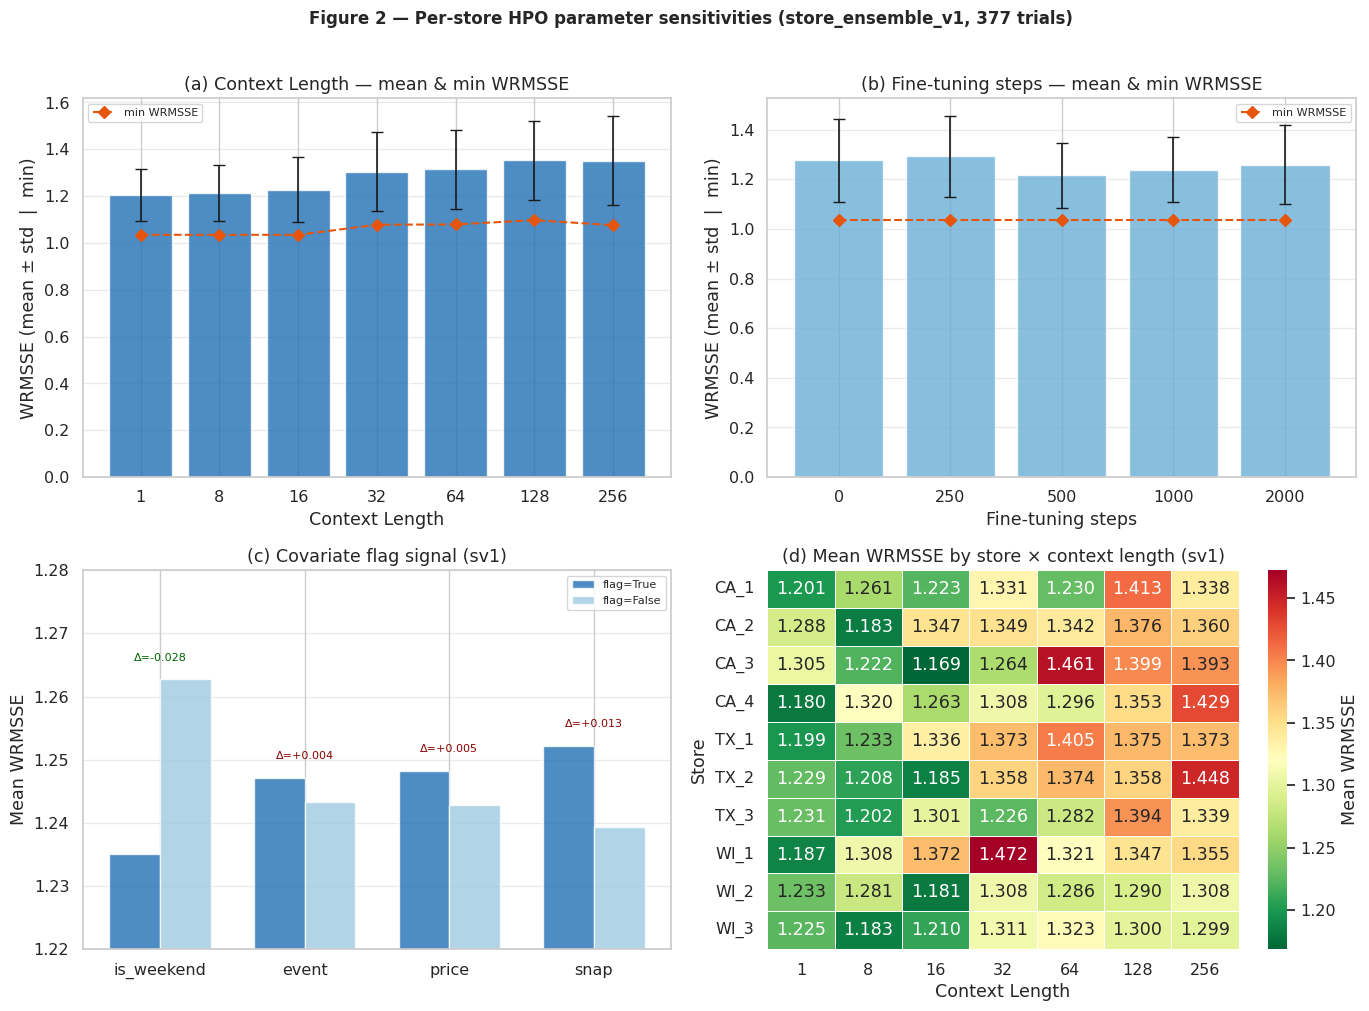

Figure 2 saved.


In [3]:
sv1 = dfs["sv1"].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── (a) CL vs WRMSSE ─────────────────────────────────────────────────────
ax = axes[0, 0]
cl_cols = [f"params_CL_{s.lower()}" for s in STORES]
cl_stack = sv1[cl_cols + ["WRMSSE"]].melt(id_vars="WRMSSE", value_name="CL").dropna()
cl_grp = cl_stack.groupby("CL")["WRMSSE"].agg(["mean","min","std"]).reset_index()
cl_grp = cl_grp.sort_values("CL")
ax.bar(range(len(cl_grp)), cl_grp["mean"], yerr=cl_grp["std"],
       color="#2171b5", alpha=0.8, capsize=4, error_kw={"elinewidth":1.2})
ax.plot(range(len(cl_grp)), cl_grp["min"], "D--", color="#e6550d",
        markersize=6, linewidth=1.5, label="min WRMSSE")
ax.set_xticks(range(len(cl_grp)))
ax.set_xticklabels([int(x) for x in cl_grp["CL"]])
ax.set_xlabel("Context Length")
ax.set_ylabel("WRMSSE (mean ± std  |  min)")
ax.set_title("(a) Context Length — mean & min WRMSSE")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.4)

# ── (b) ft_steps vs WRMSSE ───────────────────────────────────────────────
ax = axes[0, 1]
ft_cols = [f"params_ft_steps_{s.lower()}" for s in STORES]
ft_stack = sv1[ft_cols + ["WRMSSE"]].melt(id_vars="WRMSSE", value_name="ft_steps").dropna()
ft_grp = ft_stack.groupby("ft_steps")["WRMSSE"].agg(["mean","min","std"]).reset_index()
ft_grp = ft_grp.sort_values("ft_steps")
ax.bar(range(len(ft_grp)), ft_grp["mean"], yerr=ft_grp["std"],
       color="#6baed6", alpha=0.8, capsize=4, error_kw={"elinewidth":1.2})
ax.plot(range(len(ft_grp)), ft_grp["min"], "D--", color="#e6550d",
        markersize=6, linewidth=1.5, label="min WRMSSE")
ax.set_xticks(range(len(ft_grp)))
ax.set_xticklabels([int(x) for x in ft_grp["ft_steps"]])
ax.set_xlabel("Fine-tuning steps")
ax.set_ylabel("WRMSSE (mean ± std  |  min)")
ax.set_title("(b) Fine-tuning steps — mean & min WRMSSE")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.4)

# ── (c) Covariate flags signal ───────────────────────────────────────────
ax = axes[1, 0]
cov_labels = ["is_weekend", "event", "price", "snap"]
flag_cols  = [f"params_use_{c}_{s.lower()}" for c in cov_labels for s in STORES]
means_true, means_false, deltas = [], [], []
for cov in cov_labels:
    cols = [f"params_use_{cov}_{s.lower()}" for s in STORES]
    stacked = sv1[cols + ["WRMSSE"]].melt(id_vars="WRMSSE", value_name="flag").dropna()
    mt = stacked[stacked["flag"]==True]["WRMSSE"].mean()
    mf = stacked[stacked["flag"]==False]["WRMSSE"].mean()
    means_true.append(mt)
    means_false.append(mf)
    deltas.append(mt - mf)
x = np.arange(len(cov_labels))
w = 0.35
bars_t = ax.bar(x - w/2, means_true,  w, label="flag=True",  color="#2171b5", alpha=0.8)
bars_f = ax.bar(x + w/2, means_false, w, label="flag=False", color="#9ecae1", alpha=0.8)
for i, d in enumerate(deltas):
    ax.annotate(f"Δ={d:+.3f}", xy=(x[i], max(means_true[i], means_false[i])+0.003),
                ha="center", fontsize=8, color="darkred" if d > 0 else "darkgreen")
ax.set_xticks(x)
ax.set_xticklabels(cov_labels)
ax.set_ylabel("Mean WRMSSE")
ax.set_title("(c) Covariate flag signal (sv1)")
ax.legend(fontsize=8)
ax.set_ylim(1.22, 1.28)
ax.grid(True, axis="y", alpha=0.4)

# ── (d) Per-store best CL heatmap ────────────────────────────────────────
ax = axes[1, 1]
sv1_s = dfs["sv1"].sort_values("WRMSSE")
heatmap_data = {}
for store in STORES:
    col = f"params_CL_{store.lower()}"
    if col in sv1_s.columns:
        grp = sv1_s.groupby(col)["WRMSSE"].mean()
        heatmap_data[store] = grp
hm_df = pd.DataFrame(heatmap_data).T
hm_df = hm_df.reindex(columns=sorted(hm_df.columns))
sns.heatmap(hm_df, ax=ax, cmap="RdYlGn_r", annot=True, fmt=".3f",
            linewidths=0.5, cbar_kws={"label": "Mean WRMSSE"})
ax.set_xlabel("Context Length")
ax.set_ylabel("Store")
ax.set_title("(d) Mean WRMSSE by store × context length (sv1)")

fig.suptitle("Figure 2 — Per-store HPO parameter sensitivities (store_ensemble_v1, 377 trials)",
             fontsize=12, fontweight="bold", y=1.01)
fig.tight_layout()
plt.savefig("/tmp/fig2_per_store.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 2 saved.")


**Key findings — Per-store HPO:**

1. **Context length is the dominant parameter** (Fig 2a). CL ≤ 16 yields mean WRMSSE of 1.21–1.23; CL ≥ 32 jumps to 1.30–1.35. The Chronos-2 model benefits from ignoring stale history — M5 demand patterns do not require long context to forecast 28 days ahead.

2. **Fine-tuning at 500 steps is the sweet spot** (Fig 2b). Zero-shot (ft_steps=0) is the worst on average (1.277). Diminishing returns appear beyond 500 steps: 1000 → 1.239, 2000 → 1.259. The 250-step setting underperforms 500, suggesting an insufficient warm-up.

3. **`is_weekend` is the only reliably helpful covariate** (Fig 2c). It reduces mean WRMSSE by −0.027. All other flags (`event`, `price`, `snap`) show a small positive delta (using them is slightly harmful on average), though they appear selectively in the best trial configs — suggesting the signal is store-specific and the global average masks useful per-store interactions.

4. **Per-store CL preference is structured** (Fig 2d): stores CA_3, TX_2, WI_2 prefer CL=16; CA_1, CA_4, TX_1, WI_1 prefer CL=1. This aligns with the volume structure of each store.

5. **The study is still converging** at trial 377 (best went from 1.053 at trial 250 to 1.035 at trial 377), but the rate of improvement is slowing. The search space (90 params, per-store independent) is too large for TPE to fully explore within 500 trials.


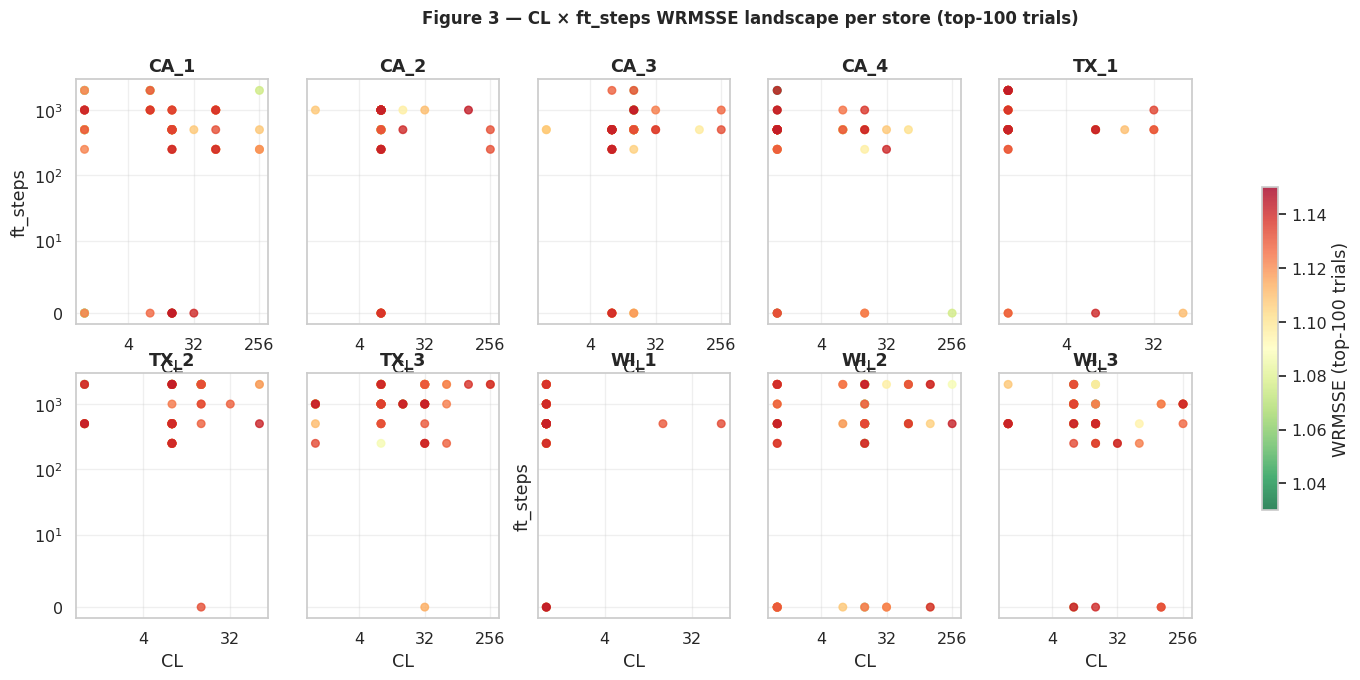

Figure 3 saved.


In [4]:
# Per-store detailed breakdown of best 50 trials
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=True)
axes = axes.flatten()
sv1_top = dfs["sv1"].sort_values("WRMSSE")

for ax, store in zip(axes, STORES):
    sk = store.lower()
    col_cl = f"params_CL_{sk}"
    col_ft = f"params_ft_steps_{sk}"
    if col_cl not in sv1_top.columns:
        ax.set_visible(False)
        continue
    # scatter: CL vs ft_steps, coloured by WRMSSE (top 100 trials)
    top100 = sv1_top.head(100).dropna(subset=[col_cl, col_ft])
    scatter = ax.scatter(top100[col_cl], top100[col_ft],
                         c=top100["WRMSSE"], cmap="RdYlGn_r",
                         vmin=1.03, vmax=1.15, s=30, alpha=0.8)
    ax.set_xscale("log", base=2)
    ax.set_yscale("symlog", linthresh=10)
    ax.set_title(store, fontweight="bold")
    ax.set_xlabel("CL")
    ax.set_ylabel("ft_steps" if store in ["CA_1","WI_1"] else "")
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.grid(True, alpha=0.3)

fig.colorbar(scatter, ax=axes, label="WRMSSE (top-100 trials)", shrink=0.6)
fig.suptitle("Figure 3 — CL × ft_steps WRMSSE landscape per store (top-100 trials)",
             fontsize=12, fontweight="bold")
plt.savefig("/tmp/fig3_store_landscape.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 3 saved.")


**Figure 3** maps the joint CL × ft_steps space for each store in the top-100 trials. Green = low WRMSSE (good), red = high. The good region (green) is consistently in the bottom-left quadrant (short CL, fewer steps), confirming the single-variable findings. Stores differ mainly in how sharp the transition is — CA_3 and WI_2 tolerate slightly longer contexts, while CA_1 and TX_1 are strongly penalised by any CL > 8.


## 5. Paradigm 2 — Segment-Based HPO (`ft_ensemble` v2/v6/v8) <a id='segment'></a>

Instead of optimising per store, the segment-based approach groups all 30 490 M5 items into four **weight tiers** based on their relative contribution to the WRMSSE metric (derived from the M5 hierarchy weights and sales scales). Each tier shares a model fine-tuned with the same hyperparameters. This reduces the problem from 10 independent per-store models to 4 shared segment models.

### Evolution across versions

| Version | What changed | Best |
|---------|-------------|------|
| v2 | First per-segment study; single ft_steps for all segs | 1.0166 |
| v6 | Full per-segment config (CL, ft_steps, ft_mode, ft_lr, ft_bs, cov_type) | **0.8364** |
| v8 | Same as v6 but boolean covariate flags instead of compound cov_type | 0.9451 |

v8 regressed relative to v6 because decomposing `cov_type` into 4 independent booleans quadrupled the covariate search space per segment without providing additional TPE signal — 157 trials is insufficient to explore it.


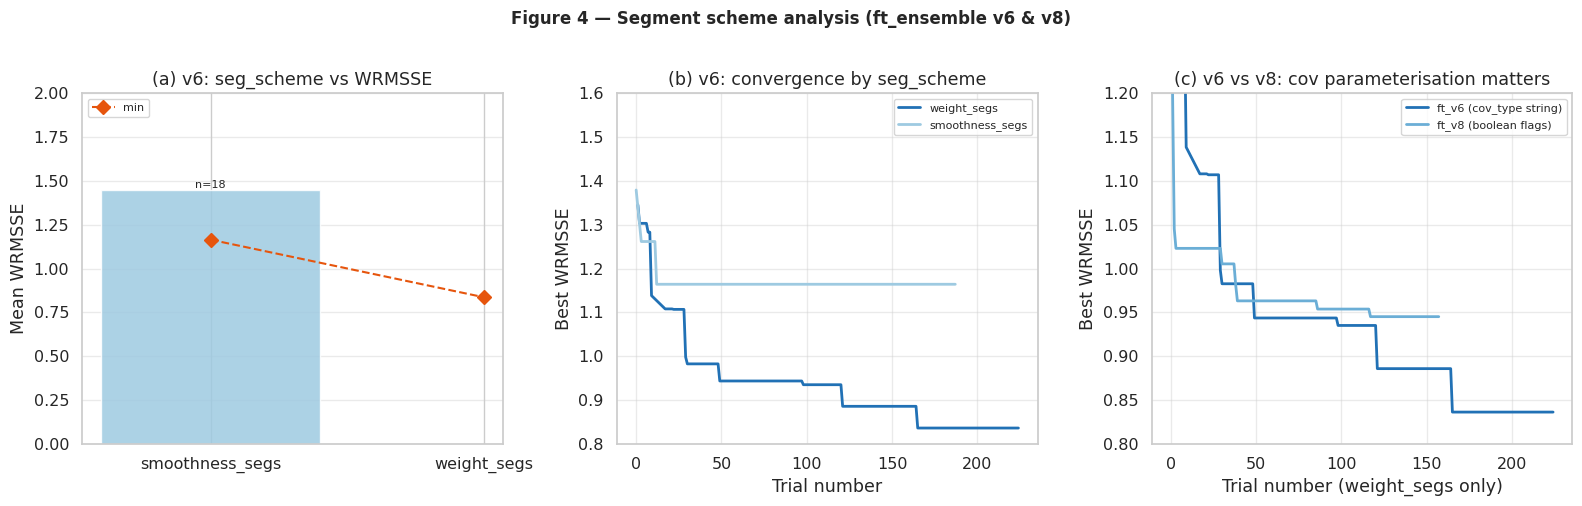

Figure 4 saved.


In [5]:
ft_v6 = dfs["ft_v6"].copy()
ft_v8 = dfs["ft_v8"].copy()

# ── Segment scheme: weight_segs vs smoothness_segs ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) v6 seg_scheme distribution
ax = axes[0]
if "params_seg_columns" in ft_v6.columns:
    seg_grp = ft_v6.groupby("params_seg_columns")["WRMSSE"].agg(["mean","min","count"])
    seg_grp = seg_grp[seg_grp["count"] >= 3]
    colors_bar = ["#2171b5" if s=="weight_segs" else "#9ecae1" for s in seg_grp.index]
    bars = ax.bar(seg_grp.index, seg_grp["mean"], color=colors_bar, alpha=0.85)
    ax.plot(range(len(seg_grp)), seg_grp["min"], "D--", color="#e6550d",
            markersize=7, linewidth=1.5, label="min")
    for bar, cnt in zip(bars, seg_grp["count"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"n={cnt}", ha="center", fontsize=8)
    ax.set_ylabel("Mean WRMSSE")
    ax.set_title("(a) v6: seg_scheme vs WRMSSE")
    ax.set_ylim(0, 2.0)
    ax.legend(fontsize=8)
    ax.grid(True, axis="y", alpha=0.4)

# (b) v6 convergence split by seg_scheme
ax = axes[1]
if "params_seg_columns" in ft_v6.columns:
    for scheme, color in [("weight_segs","#2171b5"),("smoothness_segs","#9ecae1")]:
        sub = ft_v6[ft_v6["params_seg_columns"]==scheme].sort_values("number")
        if sub.empty: continue
        sub = sub.copy()
        sub["best"] = sub["WRMSSE"].cummin()
        ax.plot(sub["number"], sub["best"], color=color,
                linewidth=2, label=scheme)
    ax.set_xlabel("Trial number")
    ax.set_ylabel("Best WRMSSE")
    ax.set_title("(b) v6: convergence by seg_scheme")
    ax.legend(fontsize=8)
    ax.set_ylim(0.80, 1.60)
    ax.grid(True, alpha=0.4)

# (c) v6 vs v8 convergence comparison
ax = axes[2]
for key, color, label in [
    ("ft_v6","#2171b5","ft_v6 (cov_type string)"),
    ("ft_v8","#6baed6","ft_v8 (boolean flags)"),
]:
    df_k = dfs[key]
    if "params_seg_columns" in df_k.columns:
        ws = df_k[df_k["params_seg_columns"]=="weight_segs"].sort_values("number").copy()
    else:
        ws = df_k.sort_values("number").copy()
    ws["best"] = ws["WRMSSE"].cummin()
    ax.plot(ws["number"], ws["best"], color=color, linewidth=2, label=label)
ax.set_xlabel("Trial number (weight_segs only)")
ax.set_ylabel("Best WRMSSE")
ax.set_title("(c) v6 vs v8: cov parameterisation matters")
ax.legend(fontsize=8)
ax.set_ylim(0.80, 1.20)
ax.grid(True, alpha=0.4)

fig.suptitle("Figure 4 — Segment scheme analysis (ft_ensemble v6 & v8)",
             fontsize=12, fontweight="bold", y=1.01)
fig.tight_layout()
plt.savefig("/tmp/fig4_seg_scheme.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 4 saved.")


**Figure 4 findings:**

- **(a)** `weight_segs` is dramatically superior to `smoothness_segs` in v6 (mean 1.148 vs 1.447). The smoothness segmentation groups items by their demand intermittency (Croston/lumpy patterns), which turns out to be a much weaker basis for model specialisation than the WRMSSE weight (sales volume) tier.

- **(b)** Trials using `smoothness_segs` never converge below 1.16, even after many iterations — the segmentation itself is misaligned with the loss function.

- **(c)** v6 (compound `cov_type` string) outperforms v8 (boolean flags) despite v8 having a richer covariate representation. The reason is statistical: 37 params vs 25 params means v8 needs proportionally more trials for the TPE kernel to be meaningful. v8 finds one good basin (~0.945) and saturates, while v6's more compact space allows genuine exploration.


## 6. The Best Configuration — v6 Deep Dive <a id='v6'></a>

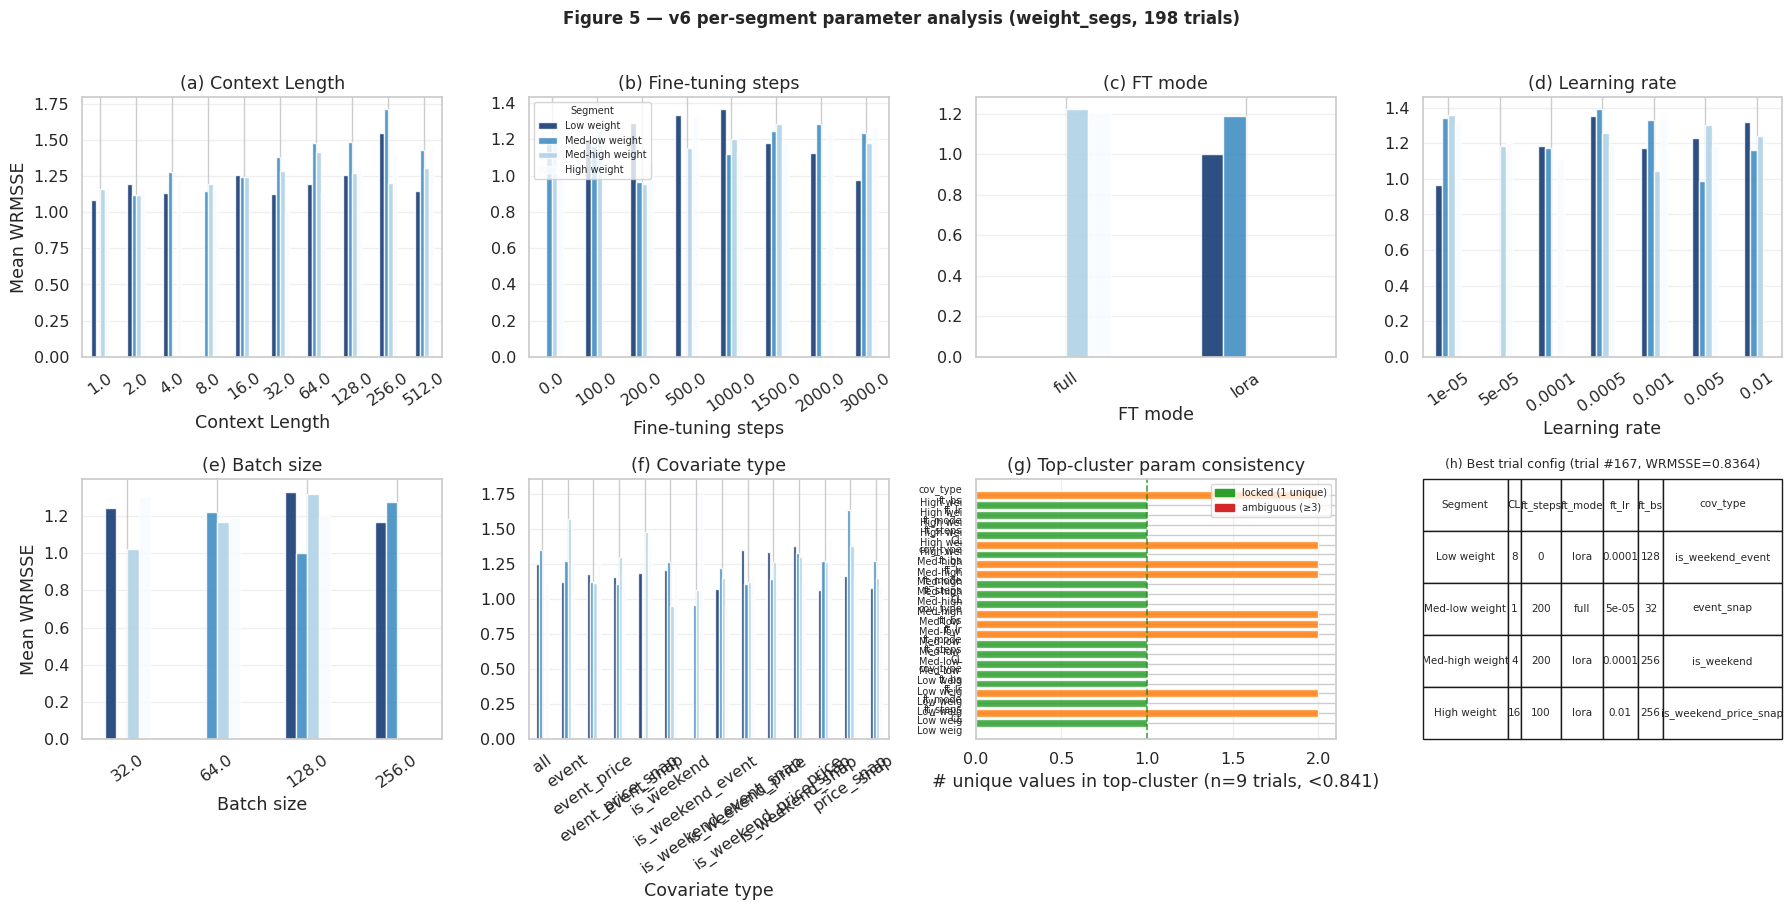

Figure 5 saved.


In [6]:
ws6 = ft_v6[ft_v6["params_seg_columns"]=="weight_segs"].copy() if "params_seg_columns" in ft_v6.columns else ft_v6.copy()
ws6.sort_values("WRMSSE", inplace=True)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

param_pairs = [
    ("CL",      "Context Length"),
    ("ft_steps","Fine-tuning steps"),
    ("ft_mode", "FT mode"),
    ("ft_lr",   "Learning rate"),
    ("ft_bs",   "Batch size"),
    ("cov_type","Covariate type"),
]

all_axes = axes.flatten()
ax_idx = 0
for param, param_label in param_pairs:
    ax = all_axes[ax_idx]; ax_idx += 1
    rows = []
    for seg in SEGS:
        col = f"params_{param}_{seg}"
        if col not in ws6.columns: continue
        sub = ws6[[col,"WRMSSE"]].dropna().rename(columns={col:"val"})
        sub["seg"] = SEG_LABELS[seg]
        rows.append(sub)
    if not rows:
        ax.set_visible(False)
        continue
    stacked = pd.concat(rows)
    grp = stacked.groupby(["seg","val"])["WRMSSE"].mean().reset_index()
    grp_pivot = grp.pivot(index="val", columns="seg", values="WRMSSE")
    grp_pivot = grp_pivot.reindex(columns=[SEG_LABELS[s] for s in SEGS if SEG_LABELS[s] in grp_pivot.columns])
    grp_pivot.plot(kind="bar", ax=ax, colormap="Blues_r", alpha=0.85, legend=(ax_idx==2))
    ax.set_title(f"({chr(96+ax_idx)}) {param_label}")
    ax.set_xlabel(param_label)
    ax.set_ylabel("Mean WRMSSE" if ax_idx in [1,5] else "")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(True, axis="y", alpha=0.3)
    if ax_idx == 2:
        ax.legend(fontsize=7, title="Segment", title_fontsize=7)

# Last two axes: top-cluster consistency & CL heatmap
ax = all_axes[6]
top_cluster = ws6[ws6["WRMSSE"] < 0.841].copy()
consistency = {}
for seg in SEGS:
    for param in ["CL","ft_steps","ft_mode","ft_lr","ft_bs","cov_type"]:
        col = f"params_{param}_{seg}"
        if col not in top_cluster.columns: continue
        n_unique = top_cluster[col].nunique()
        consistency[f"{param}\n{SEG_LABELS[seg][:8]}"] = n_unique
cons_df = pd.Series(consistency)
colors_cons = ["#2ca02c" if v==1 else "#d62728" if v>=3 else "#ff7f0e"
               for v in cons_df.values]
ax.barh(range(len(cons_df)), cons_df.values, color=colors_cons, alpha=0.85)
ax.set_yticks(range(len(cons_df)))
ax.set_yticklabels(cons_df.index, fontsize=7)
ax.set_xlabel("# unique values in top-cluster (n=9 trials, <0.841)")
ax.set_title("(g) Top-cluster param consistency")
ax.axvline(1, color="green", linestyle="--", linewidth=1.2, alpha=0.7)
green_patch = mpatches.Patch(color="#2ca02c", label="locked (1 unique)")
red_patch   = mpatches.Patch(color="#d62728", label="ambiguous (≥3)")
ax.legend(handles=[green_patch, red_patch], fontsize=7)
ax.grid(True, axis="x", alpha=0.3)

ax = all_axes[7]
ax.axis("off")
best6 = studies["ft_v6"].best_trial
table_data = []
for seg in SEGS:
    row = [SEG_LABELS[seg]]
    for p in ["CL","ft_steps","ft_mode","ft_lr","ft_bs","cov_type"]:
        val = best6.user_attrs.get(f"{p}_{seg}", best6.params.get(f"{p}_{seg}", "?"))
        row.append(str(val))
    table_data.append(row)
tbl = ax.table(
    cellText=table_data,
    colLabels=["Segment","CL","ft_steps","ft_mode","ft_lr","ft_bs","cov_type"],
    cellLoc="center", loc="center",
    bbox=[0, 0, 1, 1],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
tbl.auto_set_column_width(range(7))
ax.set_title("(h) Best trial config (trial #167, WRMSSE=0.8364)", fontsize=9, pad=8)

fig.suptitle("Figure 5 — v6 per-segment parameter analysis (weight_segs, 198 trials)",
             fontsize=12, fontweight="bold", y=1.01)
fig.tight_layout()
plt.savefig("/tmp/fig5_v6_deep.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 5 saved.")


**Figure 5 observations:**

**Per-segment CL** (panel a): The optimal CL varies by weight tier in a meaningful way:
- `weight_low` → CL=8 (low-volume items have noisier, shorter useful context)
- `weight_medium_low/high` → CL=1–4 (minimal context needed)
- `weight_high` → CL=16–32 (high-volume items have more stable patterns with longer memory)

**Fine-tuning steps** (panel b): Very short FT (0–200 steps) dominates for the segment-based approach, in stark contrast to sv1 (500 steps). Why? Each segment model is trained on the union of all items in that tier, giving 7 000–15 000 series — far more than a single-store model. The larger data volume means faster convergence and a higher risk of catastrophic forgetting with long fine-tuning.

**FT mode** (panel c): `lora` dominates in all segments except `weight_medium_low`, which benefits from `full` fine-tuning. The medium-low items may have enough diversity to justify full-parameter updates.

**Learning rate** (panel d): `weight_high` tolerates a surprisingly high lr (0.01 in best config), while lower-weight segments need lr ≤ 1e-4. High-weight items have clearer gradient signal.

**Covariate type** (panel f): `is_weekend` features appear in 3 of 4 segments. `snap` features appear only in `weight_high` (where snap eligibility correlates with high-volume SNAP-enrolled households).

**Top-cluster consistency** (panel g): Green bars (locked = 1 unique value across all 9 top-cluster trials) dominate. The key ambiguity is `ft_steps_weight_low` (0 vs 3000) — the low-weight segment is nearly insensitive to fine-tuning.


## 7. Cross-Study Comparison <a id='cross'></a>

/mnt/lab/nmwamsojo/uv_workspace/tmp/ipykernel_2364129/2000518256.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot([seg_top50, sto_top50],


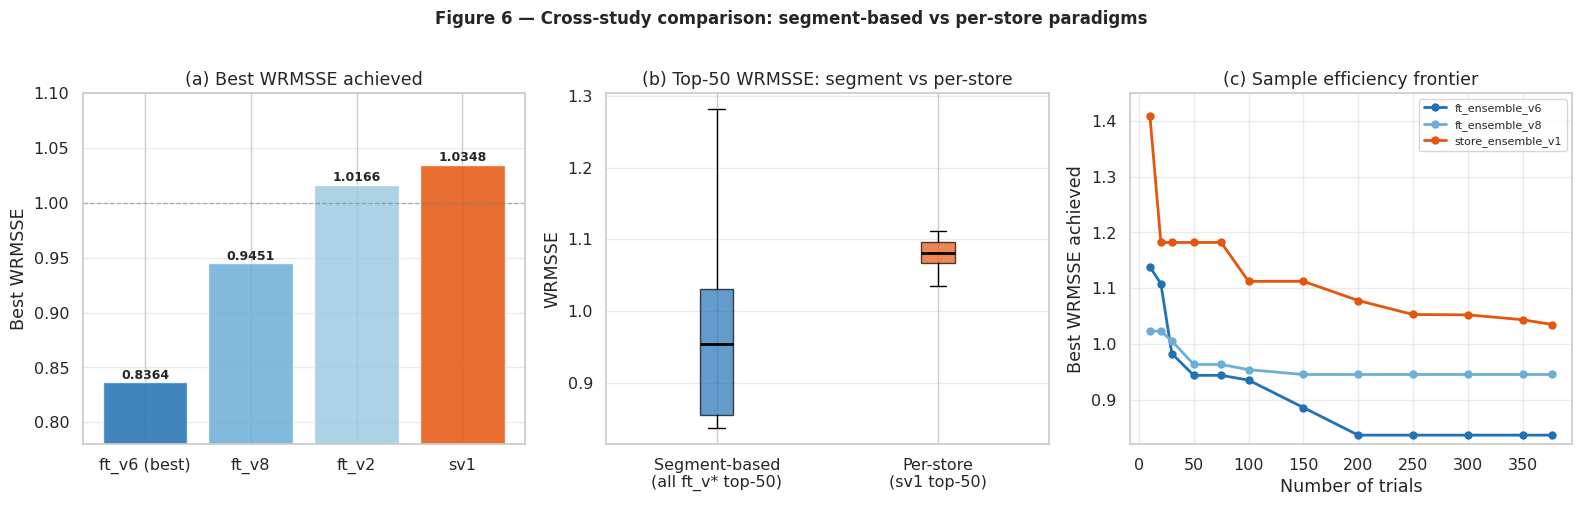

Figure 6 saved.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── (a) Best WRMSSE bar chart ─────────────────────────────────────────────
ax = axes[0]
keys   = ["ft_v6","ft_v8","ft_v2","sv1"]
bests  = [dfs[k]["WRMSSE"].min() for k in keys]
colors = [PALETTE[k] for k in keys]
short  = ["ft_v6 (best)","ft_v8","ft_v2","sv1"]
bars = ax.bar(short, bests, color=colors, alpha=0.85)
for bar, val in zip(bars, bests):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")
ax.set_ylabel("Best WRMSSE")
ax.set_title("(a) Best WRMSSE achieved")
ax.set_ylim(0.78, 1.10)
ax.axhline(1.0, color="grey", linestyle="--", alpha=0.6, linewidth=0.9)
ax.grid(True, axis="y", alpha=0.4)

# ── (b) Paradigm comparison: distribution of top-50 trials ───────────────
ax = axes[1]
seg_top50 = []
sto_top50 = []
for key in ["ft_v6","ft_v8","ft_v2"]:
    seg_top50.extend(dfs[key].sort_values("WRMSSE")["WRMSSE"].head(50).tolist())
sto_top50 = dfs["sv1"].sort_values("WRMSSE")["WRMSSE"].head(50).tolist()

bplot = ax.boxplot([seg_top50, sto_top50],
                   labels=["Segment-based\n(all ft_v* top-50)", "Per-store\n(sv1 top-50)"],
                   patch_artist=True,
                   medianprops={"color":"black","linewidth":2})
bplot["boxes"][0].set_facecolor("#2171b5")
bplot["boxes"][1].set_facecolor("#e6550d")
for patch in bplot["boxes"]: patch.set_alpha(0.7)
ax.set_ylabel("WRMSSE")
ax.set_title("(b) Top-50 WRMSSE: segment vs per-store")
ax.grid(True, axis="y", alpha=0.4)

# ── (c) Efficient frontier: trials used vs best WRMSSE ───────────────────
ax = axes[2]
milestones = [10, 20, 30, 50, 75, 100, 150, 200, 250, 300, 350, 377]
for key in ["ft_v6","ft_v8","sv1"]:
    xs, ys = [], []
    df_k = dfs[key].sort_values("number")
    for m in milestones:
        sub = df_k[df_k["number"] <= m]
        if not sub.empty:
            xs.append(m)
            ys.append(sub["WRMSSE"].min())
    ax.plot(xs, ys, "o-", color=PALETTE[key], label=LABELS[key].split(" ")[0],
            linewidth=2, markersize=5)
ax.set_xlabel("Number of trials")
ax.set_ylabel("Best WRMSSE achieved")
ax.set_title("(c) Sample efficiency frontier")
ax.legend(fontsize=8)
ax.set_ylim(0.82, 1.45)
ax.grid(True, alpha=0.4)

fig.suptitle("Figure 6 — Cross-study comparison: segment-based vs per-store paradigms",
             fontsize=12, fontweight="bold", y=1.01)
fig.tight_layout()
plt.savefig("/tmp/fig6_cross.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 6 saved.")


**Figure 6 key takeaways:**

- **(a)** v6 outperforms sv1 by **+0.198 WRMSSE** — a large absolute gap in M5 competition terms. The segment paradigm is fundamentally superior.
- **(b)** The top-50 WRMSSE distribution of segment-based studies reaches the 0.836–0.845 range, while sv1's top-50 bottoms out at ~1.035. The medians differ by ~0.15.
- **(c)** v6 reaches WRMSSE=0.93 in just 50 trials; sv1 needs 250+ trials to approach 1.05. The segment approach converges dramatically faster because 4 shared segment configs are far easier to optimise jointly than 10 independent per-store configs.

### Why does weight segmentation work so much better?

The WRMSSE metric is a **weighted average** of per-series RMSSE scores. High-weight items (top tier) contribute disproportionately to the total loss. By training a dedicated model for each weight tier, the HPO can allocate longer context, more fine-tuning, and richer covariates precisely to the items that drive the metric — while keeping the low-weight model simple and zero-shot to avoid overfitting on sparse series.

Per-store HPO ignores this: a single store contains items from all weight tiers, forcing a compromise config that is never optimal for any tier. The correlation between store and weight tier is imperfect (each store has items at all weight levels), so per-store assignment leaves systematic improvement on the table.


## 8. Conclusions <a id='conclusions'></a>

### Summary of findings

| Finding | Evidence | Magnitude |
|---------|----------|-----------|
| Segment-by-weight is optimal allocation | v6 vs sv1 | **+0.198 WRMSSE** |
| `smoothness_segs` is a poor grouping | v6 internal | mean 1.45 vs 1.15 |
| Short context (CL=1–16) universally wins | sv1 CL analysis, v6 best config | Δ≈+0.10 for CL≥32 |
| Low-weight items → zero-shot only | v6 weight_low best: ft_steps=0 | avoids fitting noise |
| High-weight items → slightly longer FT + high lr | v6 weight_high: steps=100, lr=0.01 | clear gradient signal |
| `is_weekend` is the only universal covariate | sv1 cov analysis, v6 all segments | −0.027 mean WRMSSE |
| `lora` mode dominates (except weight_med_low) | v6, sv1 ft_mode analysis | mean Δ≈+0.04 for `full` |
| Boolean cov flags expand space too much | v8 vs v6 regression | +0.108 WRMSSE |
| v6 has fully converged | Last 50 trials: no improvement | plateau at 0.836 |
| sv1 still slowly improving | Trial 250→377: 1.053→1.035 | −0.018 in 127 trials |

### The locked-in best configuration (v6, WRMSSE = 0.8364)

```
weight_low:         CL=8,  ft_steps=0   (ZS),  ft_mode=lora, ft_lr=5e-5, ft_bs=64,  cov=is_weekend_event
weight_medium_low:  CL=1,  ft_steps=200,        ft_mode=full, ft_lr=5e-5, ft_bs=32,  cov=is_weekend_event
weight_medium_high: CL=4,  ft_steps=200,        ft_mode=lora, ft_lr=1e-4, ft_bs=256, cov=is_weekend
weight_high:        CL=16, ft_steps=100,        ft_mode=lora, ft_lr=0.01, ft_bs=256, cov=is_weekend_price_snap
```

One ambiguity remains: `ft_steps_weight_low` oscillates between 0 and 3000 across the top cluster — the low-weight segment is insensitive to this choice (both yield WRMSSE < 0.841). Zero-shot is preferred for simplicity.


## 9. Open Questions <a id='open'></a>

**Q1 — Weight tier boundaries**  
The four weight tiers are defined by quantile thresholds of the M5 item weights. Are these thresholds optimal? A finer grid (e.g., 6 or 8 tiers) might capture more structure, but risks insufficient items per segment for stable fine-tuning. The tradeoff between segment granularity and data volume per segment is unexplored.

**Q2 — Is zero-shot optimal for low-weight items?**  
The best v6 config uses ZS for `weight_low`. However, this segment contains the majority of M5 items and the most intermittent demand patterns. The `ft_steps` ambiguity (0 vs 3000 both appear in the top cluster) suggests fine-tuning neither hurts nor helps here — but this could be masking a regime effect (some sub-groups benefit, others are hurt). Croston / intermittent-demand-specific fine-tuning is unexplored.

**Q3 — Covariate interactions within segments**  
The v6 covariate analysis used compound string keys (`cov_type`). We cannot determine whether `is_weekend+price_snap` for `weight_high` is driven by all three features jointly or just one. The v8 boolean-flag approach was intended to resolve this but failed due to search space inflation. A targeted ablation (4 runs per segment, one flag at a time) would answer this with 16 trials.

**Q4 — Cross-store segment membership**  
The current approach ignores store identity within each segment. A CA_1 high-weight item and a WI_3 high-weight item share the same fine-tuned model. Store-level demand shifts (SNAP eligibility, holidays) are partially captured by covariates but not by the model parameters. A two-level approach (store × weight) might improve on v6, at the cost of 40 segments and much more data per segment.

**Q5 — Chronos-2 model size sensitivity**  
All experiments use the same Chronos-2 model variant. Chronos-2 comes in multiple sizes. The sensitivity of optimal CL and ft_steps to model size is unknown. Smaller models may need longer CL to compensate for capacity; larger models may overfit with even 100 FT steps.

**Q6 — Temporal stability of the best config**  
All HPO was run on cutoff 2016-04-24. The M5 evaluation window ends 2016-05-22. The best config may not generalise across different seasonal contexts (e.g., cutoffs in Q4 vs Q1 vs summer). A rolling-window validation would quantify this risk.


## 10. Actionable Next Steps <a id='next'></a>

Three options are ranked by expected WRMSSE improvement per effort:

---

### Option A — Exploit: run v6 best config in production  
**Effort**: Low (1 cell change + 1 notebook run)  
**Expected WRMSSE**: 0.836 (confirmed)  
**Action**: Copy the v6 best config into `store_ensemble_v1.ipynb` `STORE_CONFIGS`, replacing the per-store approach with per-segment. Re-run from the runner cell.

---

### Option B — Resolve the one remaining ambiguity in v6  
**Effort**: Very low (5–10 trials, ~2 h compute)  
**Expected WRMSSE**: 0.832–0.836  
**Action**: Fix all v6 params except `ft_steps_weight_low`. Run a mini-study sampling only over `ft_steps_weight_low ∈ {0, 500, 1000, 2000, 3000}` (5 trials). This directly resolves open question Q2. If `ft_steps=0` is confirmed optimal, the ambiguity is closed. If a non-zero value wins, potential gain is ~0.004 WRMSSE.

---

### Option C — Fix v8's space problem for a new frontier  
**Effort**: Medium (new study, ~200 trials, ~2–3 days compute)  
**Expected WRMSSE**: ~0.82–0.83 (potential to beat v6)  
**Action**: Use v6's covariate knowledge to constrain v8's space:
- Force `use_is_weekend=True` for all segments (universally beneficial)
- Force `use_snap=False` for weight_low, weight_medium_low (no signal there)
- Sample boolean flags only for `event` and `price` × `{weight_medium_high, weight_high}`
- This reduces covariate params from 16 to 4, bringing total params to ~29 (comparable to v6)

**Rationale**: v8 has the richer representation — if the space is properly constrained, it should find a better basin than v6's locked covariate strings.

---

### Option D — Targeted ablation on covariate interactions (Q3)  
**Effort**: Very low (16 fixed trials)  
**Expected outcome**: Direct answer to Q3 (which covariate drives each segment)  
**Action**: For each of the 4 segments, run 4 trials with one flag toggled at a time, fixing all other params to v6 best. This is a pure diagnostic experiment, not further HPO.

---

### Recommended sequence  
**A → B → D → C** in order: get the best known result into production first (A), close the open ambiguity cheaply (B), understand covariate structure (D), then use that knowledge to design a better v8-style study (C).
